In [1]:
from pathlib import Path
import pandas as pd
import os, math, time, random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupKFold

def set_seed(seed: int = 22):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(27)

DATA_DIR = Path('/kaggle/input/competitions/champs-scalar-coupling')

train = pd.read_csv(DATA_DIR / 'train.csv')
structures = pd.read_csv(DATA_DIR / 'structures.csv')

print("Loaded data")
print("train shape:", train.shape)
print("structures shape:", structures.shape)

Loaded data
train shape: (4659076, 6)
structures shape: (2358875, 6)


distances for the geometric branch

In [2]:
def map_atom_info(df, atom_idx):
    df = pd.merge(df, structures, how='left',
                  left_on=['molecule_name', f'atom_index_{atom_idx}'],
                  right_on=['molecule_name', 'atom_index'])
    df = df.drop('atom_index', axis=1)
    df = df.rename(columns={'atom': f'atom_{atom_idx}',
                            'x': f'x_{atom_idx}',
                            'y': f'y_{atom_idx}',
                            'z': f'z_{atom_idx}'})
    return df

# merge coordinates for both atoms
train_merged = map_atom_info(train, 0)
train_merged = map_atom_info(train_merged, 1)

# euclidean distance
train_merged['dx'] = train_merged['x_1'] - train_merged['x_0']
train_merged['dy'] = train_merged['y_1'] - train_merged['y_0']
train_merged['dz'] = train_merged['z_1'] - train_merged['z_0']
train_merged['dist'] = np.sqrt(train_merged['dx']**2 + train_merged['dy']**2 + train_merged['dz']**2)

# categorical text into int for the Embedding layer
type_dict = {t: i for i, t in enumerate(train_merged['type'].unique())}
train_merged['type_encoded'] = train_merged['type'].map(type_dict)

continuous_cols = ['dx', 'dy', 'dz', 'dist']

In [3]:
class ChampsDataset(Dataset):
    def __init__(self, df, continuous_cols):
        self.cont = df[continuous_cols].values.astype(np.float32)
        self.cat_type = df['type_encoded'].values.astype(np.int64)
        self.targets = df['scalar_coupling_constant'].values.astype(np.float32)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return {
            'cont': torch.tensor(self.cont[idx]),
            'type': torch.tensor(self.cat_type[idx]),
            'target': torch.tensor(self.targets[idx])
        }

the model

In [4]:
# custom linear layer
class SimpleCustomLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        # bias starting at zeros
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # y = (x * weight) + bias
        return F.linear(x, self.weight, self.bias)

# custom optimizer, SGD
class SimpleCustomSGD(torch.optim.Optimizer):
    def __init__(self, params, lr=0.001):
        defaults = dict(lr=lr)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is not None:
                    # Update rule: weight = weight - (learning_rate * gradient)
                    p.sub_(p.grad, alpha=lr)

# 2 branch model
class BasicTwoBranchNet(nn.Module):
    def __init__(
        self, 
        num_continuous_feats: int, 
        num_coupling_types: int = 8, 
        cat_embed_dim: int = 16, 
        hidden_dim: int = 128
    ):
        super().__init__()
        
        # branch 1, categorical
        self.type_emb = nn.Embedding(num_coupling_types, cat_embed_dim)
        
        # branch 2, continuos
        self.cont_branch = nn.Sequential(
            nn.Linear(num_continuous_feats, hidden_dim // 2),
            nn.ReLU()
        )
        
        # fusion
        fusion_dim = (hidden_dim // 2) + cat_embed_dim
        
        # deep layers
        self.network = nn.Sequential(
            SimpleCustomLinear(fusion_dim, hidden_dim),
            nn.ReLU(),
            SimpleCustomLinear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1) # final output head
        )

    def forward(self, cont_x: torch.Tensor, cat_type: torch.Tensor):
        # processing categorical
        emb = self.type_emb(cat_type)
        
        # processing coninuous
        cont_features = self.cont_branch(cont_x)
        
        # combine
        fused = torch.cat([cont_features, emb], dim=1)
        
        # predict
        prediction = self.network(fused)
        return prediction.squeeze(-1)

training

In [5]:
def train_and_visualize(model, train_loader, val_loader, optimizer, epochs=5, plot=True):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    train_losses, val_losses = [], []
    grad_norms_history = {}
    
    for name, _ in model.named_parameters():
        if 'weight' in name:
            grad_norms_history[name] = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            cont_x = batch['cont'].to(device)
            cat_type = batch['type'].to(device)
            targets = batch['target'].to(device)
            
            optimizer.zero_grad()
            preds = model(cont_x, cat_type)
            loss = F.l1_loss(preds, targets)
            loss.backward()
            
            for name, param in model.named_parameters():
                if 'weight' in name and param.grad is not None:
                    grad_norms_history[name].append(param.grad.data.norm(2).item())
                    
            optimizer.step()
            epoch_loss += loss.item()
            
        train_losses.append(epoch_loss / len(train_loader))
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                cont_x = batch['cont'].to(device)
                cat_type = batch['type'].to(device)
                targets = batch['target'].to(device)
                
                preds = model(cont_x, cat_type)
                val_loss += F.l1_loss(preds, targets).item()
                
        val_losses.append(val_loss / len(val_loader))
        print(f"Epoch {epoch+1} | Train MAE: {train_losses[-1]:.4f} | Val MAE: {val_losses[-1]:.4f}")

    if plot:
        # loss curves
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Train MAE', marker='o')
        plt.plot(val_losses, label='Validation MAE', marker='s')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

        # gradient flow
        plt.figure(figsize=(12, 6))
        for name, norms in grad_norms_history.items():
            plt.plot(norms[::50], label=name, alpha=0.6)
            
        plt.yscale('log')
        plt.title('Gradient Flow Across Layers (L2 Norm)')
        plt.xlabel('Training Steps (x50)')
        plt.ylabel('Gradient L2 Norm')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    return model, val_losses[-1]

In [6]:
# small subset of the data for speed
tune_subset = train_merged.sample(n=100000, random_state=42).reset_index(drop=True)

# 80/20 train/val split for tuning
split_idx = int(len(tune_subset) * 0.8)
tune_train_data = ChampsDataset(tune_subset.iloc[:split_idx], continuous_cols)
tune_val_data = ChampsDataset(tune_subset.iloc[split_idx:], continuous_cols)

tune_train_loader = DataLoader(tune_train_data, batch_size=256, shuffle=True)
tune_val_loader = DataLoader(tune_val_data, batch_size=512, shuffle=False)

configs = [
    {'lr': 0.01, 'hidden_dim': 64},
    {'lr': 0.001, 'hidden_dim': 128},
    {'lr': 0.005, 'hidden_dim': 128}
]

tuning_logs = []

for i, config in enumerate(configs):
    print(f"\nTesting config {i+1}: LR={config['lr']}, Hidden={config['hidden_dim']}")
    
    tune_model = BasicTwoBranchNet(
        num_continuous_feats=len(continuous_cols), 
        hidden_dim=config['hidden_dim']
    )
    
    tune_optimizer = SimpleCustomSGD(tune_model.parameters(), lr=config['lr'])
    
    _, final_val_mae = train_and_visualize(
        tune_model, tune_train_loader, tune_val_loader, tune_optimizer, epochs=1, plot=False
    )
    
    tuning_logs.append({
        'Config': i+1,
        'Learning Rate': config['lr'],
        'Hidden Dim': config['hidden_dim'],
        'Validation MAE': round(final_val_mae, 4)
    })

# logs
logs_df = pd.DataFrame(tuning_logs)
print("\nFINAL PARAMETER TUNING LOGS")
display(logs_df)

# best config selection
best_config = logs_df.loc[logs_df['Validation MAE'].idxmin()]
best_lr = best_config['Learning Rate']
best_hidden = int(best_config['Hidden Dim'])

print(f"\nSelected best parameters: LR={best_lr}, Hidden={best_hidden}")


Testing config 1: LR=0.01, Hidden=64


Epoch 1/1:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 | Train MAE: 14.0437 | Val MAE: 4.5622

Testing config 2: LR=0.001, Hidden=128


Epoch 1/1:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 | Train MAE: 18.0364 | Val MAE: 17.8348

Testing config 3: LR=0.005, Hidden=128


Epoch 1/1:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 | Train MAE: 17.2105 | Val MAE: 15.6023

FINAL PARAMETER TUNING LOGS


,Config,Learning Rate,Hidden Dim,Validation MAE
0,1,0.010,64,4.5622
1,2,0.001,128,17.8348
2,3,0.005,128,15.6023



Selected best parameters: LR=0.01, Hidden=64



STARTING FOLD 1


Epoch 1/5:   0%|          | 0/3034 [00:00<?, ?it/s]

Epoch 1 | Train MAE: 4.9768 | Val MAE: 3.7934


Epoch 2/5:   0%|          | 0/3034 [00:00<?, ?it/s]

Epoch 2 | Train MAE: 3.7781 | Val MAE: 3.7535


...

Epoch 3 | Train MAE: 3.7196 | Val MAE: 3.7013


Epoch 4/5:   0%|          | 0/3034 [00:00<?, ?it/s]

Epoch 4 | Train MAE: 3.6948 | Val MAE: 3.6855


Epoch 5/5:   0%|          | 0/3034 [00:00<?, ?it/s]

Epoch 5 | Train MAE: 3.6743 | Val MAE: 3.6840


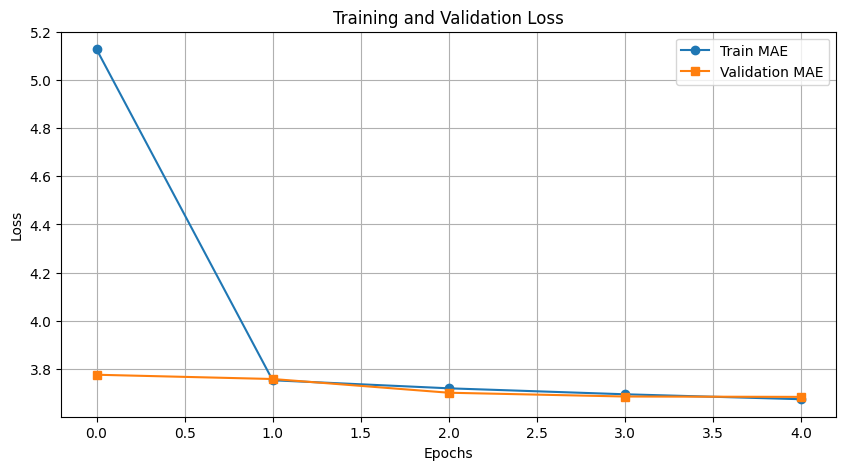

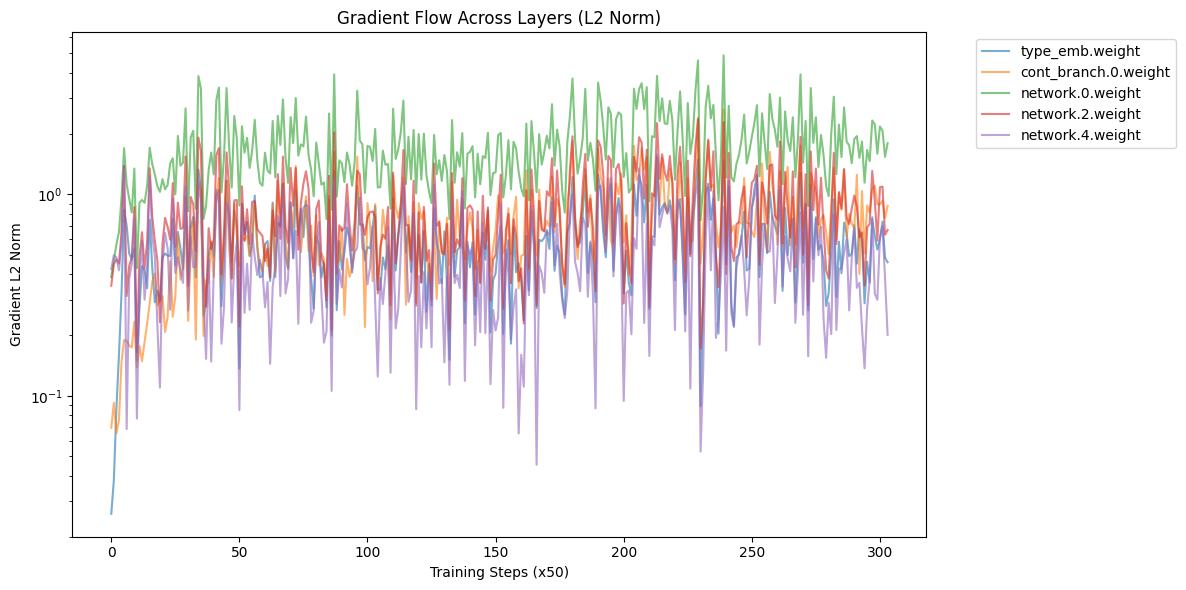

Predicting Fold 3:   0%|          | 0/1517 [00:00<?, ?it/s]


Saved dl2_oof_predictions.csv


In [7]:
train_merged['oof_dl2'] = 0.0

gkf = GroupKFold(n_splits=3) 

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_merged, groups=train_merged['molecule_name'])):
    print(f"\nSTARTING FOLD {fold+1}")
    
    train_data = ChampsDataset(train_merged.iloc[train_idx], continuous_cols)
    val_data = ChampsDataset(train_merged.iloc[val_idx], continuous_cols)
    
    train_loader = DataLoader(train_data, batch_size=1024, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=1024, shuffle=False)
    
    # chose best found params from tuning
    model = BasicTwoBranchNet(
        num_continuous_feats=len(continuous_cols),
        hidden_dim=best_hidden
    )
    
    optimizer = SimpleCustomSGD(model.parameters(), lr=best_lr)
    
    # train and plot
    should_plot = (fold == 2) # Will generate your report charts on the final fold
    model, _ = train_and_visualize(model, train_loader, val_loader, optimizer, epochs=5, plot=should_plot)
    
    # validation predictions
    model.eval()
    val_preds = []
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Predicting Fold {fold+1}"):
            preds = model(batch['cont'].to(device), batch['type'].to(device))
            val_preds.extend(preds.cpu().numpy())
            
    train_merged.loc[val_idx, 'oof_dl2'] = val_preds

# save
train_merged[['id', 'oof_dl2']].to_csv('dl2_oof_predictions.csv', index=False)
print("\nSaved dl2_oof_predictions.csv")